<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


## Hands on Lab: Complete the Machine Learning Prediction lab


Estimated time needed: **60** minutes


Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   In this lab, you will create a machine learning pipeline  to predict if the first stage will land given the data from the preceding labs.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planed. Space X; performs a controlled landing in the oceans.


## Objectives


Perform exploratory  Data Analysis and determine Training Labels

*   create a column for the class
*   Standardize the data
*   Split into training data and test data

\-Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

*   Find the method performs best using test data


## Import Libraries and Define Auxiliary Functions


In [ ]:
import piplite
await piplite.install(['numpy'])
await piplite.install(['pandas'])
await piplite.install(['seaborn'])

We will import the following libraries for the lab


In [5]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

This function is to plot the confusion matrix.


In [7]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## Load the dataframe


Load the data


In [8]:
from js import fetch
import io

URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
resp1 = await fetch(URL1)
text1 = io.BytesIO((await resp1.arrayBuffer()).to_py())
data = pd.read_csv(text1)

In [9]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [10]:
URL2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
resp2 = await fetch(URL2)
text2 = io.BytesIO((await resp2.arrayBuffer()).to_py())
X = pd.read_csv(text2)

In [11]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


## TASK  1


Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [12]:
# TASK 1: Create a NumPy array from the column Class in data
Y = data['Class'].to_numpy()

# Display information about Y
print("="*50)
print("TASK 1 COMPLETED")
print("="*50)
print(f"Y is a: {type(Y)}")
print(f"Y shape: {Y.shape}")
print(f"Y data type: {Y.dtype}")
print(f"\nFirst 10 values of Y: {Y[:10]}")
print(f"Last 10 values of Y: {Y[-10:]}")
print(f"\nUnique values in Y: {np.unique(Y)}")
print(f"Count of each class:")
print(f"  Class 0 (did not land): {np.sum(Y == 0)}")
print(f"  Class 1 (landed): {np.sum(Y == 1)}")

TASK 1 COMPLETED
Y is a: <class 'numpy.ndarray'>
Y shape: (90,)
Y data type: int64

First 10 values of Y: [0 0 0 0 0 0 1 1 0 0]
Last 10 values of Y: [1 1 1 1 1 1 1 1 1 1]

Unique values in Y: [0 1]
Count of each class:
  Class 0 (did not land): 30
  Class 1 (landed): 60


## TASK  2


Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [15]:
# students get this 
transform = preprocessing.StandardScaler()

transform = preprocessing.StandardScaler()

# If X is a DataFrame, standardize and convert back to DataFrame
X_scaled = transform.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns if hasattr(X, 'columns') else None)

# Verify
print("="*50)
print("TASK 2 COMPLETED")
print("="*50)
print("X type:", type(X))
print("X shape:", X.shape)
print("\nFirst 5 rows (first 5 columns):")
print(X.iloc[:5, :5])
print(f"\nMean of all features: {X.mean().mean():.10f}")
print(f"Standard deviation of all features: {X.std().mean():.10f}")

TASK 2 COMPLETED
X type: <class 'pandas.core.frame.DataFrame'>
X shape: (90, 83)

First 5 rows (first 5 columns):
   FlightNumber   PayloadMass   Flights     Block  ReusedCount
0     -1.712912 -1.948145e-16 -0.653913 -1.575895     -0.97344
1     -1.674419 -1.195232e+00 -0.653913 -1.575895     -0.97344
2     -1.635927 -1.162673e+00 -0.653913 -1.575895     -0.97344
3     -1.597434 -1.200587e+00 -0.653913 -1.575895     -0.97344
4     -1.558942 -6.286706e-01 -0.653913 -1.575895     -0.97344

Mean of all features: -0.0000000000
Standard deviation of all features: 1.0056022847


We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


## TASK  3


Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


<code>X_train, X_test, Y_train, Y_test</code>


In [16]:
# TASK 3: Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# Verify the split
print("="*50)
print("TASK 3 COMPLETED")
print("="*50)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")
print(f"\nTraining set size: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

# Check class distribution in training and test sets
print(f"\nClass distribution in training set:")
print(f"  Class 0: {np.sum(Y_train == 0)}")
print(f"  Class 1: {np.sum(Y_train == 1)}")
print(f"\nClass distribution in test set:")
print(f"  Class 0: {np.sum(Y_test == 0)}")
print(f"  Class 1: {np.sum(Y_test == 1)}")

TASK 3 COMPLETED
X_train shape: (72, 83)
X_test shape: (18, 83)
Y_train shape: (72,)
Y_test shape: (18,)

Training set size: 72 samples (80.0%)
Test set size: 18 samples (20.0%)

Class distribution in training set:
  Class 0: 24
  Class 1: 48

Class distribution in test set:
  Class 0: 6
  Class 1: 12


we can see we only have 18 test samples.


In [17]:
Y_test.shape

(18,)

## TASK  4


Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [18]:
# TASK 4: Create Logistic Regression with GridSearchCV
parameters = {'C': [0.01, 0.1, 1],
              'penalty': ['l2'],
              'solver': ['lbfgs']}

# Create logistic regression object
lr = LogisticRegression()

# Create GridSearchCV object with cv=10
logreg_cv = GridSearchCV(lr, parameters, cv=10)

# Fit the object to find the best parameters
logreg_cv.fit(X_train, Y_train)

# Display results
print("="*50)
print("TASK 4 COMPLETED - Logistic Regression GridSearchCV")
print("="*50)
print(f"Best parameters: {logreg_cv.best_params_}")
print(f"Best cross-validation score: {logreg_cv.best_score_:.4f}")
print(f"Test set accuracy: {logreg_cv.score(X_test, Y_test):.4f}")

# Display all results
print("\nAll CV results:")
for i, params in enumerate(logreg_cv.cv_results_['params']):
    mean_score = logreg_cv.cv_results_['mean_test_score'][i]
    std_score = logreg_cv.cv_results_['std_test_score'][i]
    print(f"  {params}: mean={mean_score:.4f}, std={std_score:.4f}")

TASK 4 COMPLETED - Logistic Regression GridSearchCV
Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validation score: 0.8464
Test set accuracy: 0.8333

All CV results:
  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}: mean=0.8464, std=0.0959
  {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}: mean=0.8214, std=0.1013
  {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}: mean=0.7929, std=0.1072


In [19]:
parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}# l1 lasso l2 ridge
lr=LogisticRegression()


We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [20]:
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.8464285714285713


## TASK  5


Calculate the accuracy on the test data using the method <code>score</code>:


In [22]:
# TASK 5: Calculate the accuracy on the test data
accuracy_test = logreg_cv.score(X_test, Y_test)

print("="*50)
print("TASK 5 COMPLETED - Logistic Regression Test Accuracy")
print("="*50)
print(f"Accuracy on test data: {accuracy_test:.4f}")
print(f"Accuracy on test data: {accuracy_test*100:.2f}%")

# Additional evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions on test set
yhat = logreg_cv.predict(X_test)

TASK 5 COMPLETED - Logistic Regression Test Accuracy
Accuracy on test data: 0.8333
Accuracy on test data: 83.33%


Lets look at the confusion matrix:


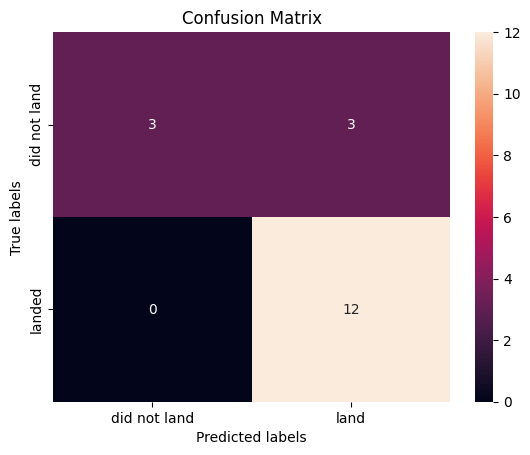

In [23]:
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

Examining the confusion matrix, we see that logistic regression can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is landed, Predicted label is also landed)

False Postive - 3 (True label is not landed, Predicted label is landed)


## TASK  6


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [24]:
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()

In [26]:
# Create GridSearchCV object with cv=10
svm_cv = GridSearchCV(svm, parameters, cv=10)

# Fit the object to find the best parameters
svm_cv.fit(X_train, Y_train)

# Display results as requested
print("="*50)
print("TASK 6 COMPLETED - SVM GridSearchCV")
print("="*50)

TASK 6 COMPLETED - SVM GridSearchCV


tuned hpyerparameters :(best parameters)  {'C': 1.0, 'gamma': 0.03162277660168379, 'kernel': 'sigmoid'}
accuracy : 0.8482142857142856

Test set accuracy: 0.8333

Confusion Matrix - SVM:
[[ 3  3]
 [ 0 12]]


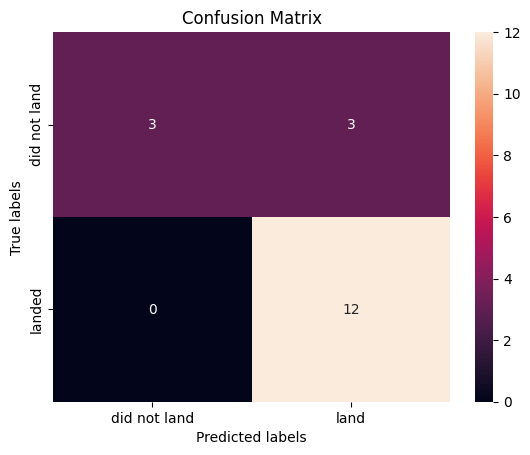

In [27]:
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)
# Additional information (optional)
print(f"\nTest set accuracy: {svm_cv.score(X_test, Y_test):.4f}")

# Get predictions and confusion matrix
Y_pred_svm = svm_cv.predict(X_test)
print("\nConfusion Matrix - SVM:")
cm_svm = confusion_matrix(Y_test, Y_pred_svm)
print(cm_svm)

# Plot confusion matrix
plot_confusion_matrix(Y_test, Y_pred_svm)

## TASK  7


Calculate the accuracy on the test data using the method <code>score</code>:


In [28]:
# TASK 7: Calculate the accuracy on the test data using the method score
accuracy_test_svm = svm_cv.score(X_test, Y_test)

print("="*50)
print("TASK 7 COMPLETED - SVM Test Accuracy")
print("="*50)
print(f"Accuracy on test data: {accuracy_test_svm:.4f}")
print(f"Accuracy on test data: {accuracy_test_svm*100:.2f}%")

TASK 7 COMPLETED - SVM Test Accuracy
Accuracy on test data: 0.8333
Accuracy on test data: 83.33%


We can plot the confusion matrix


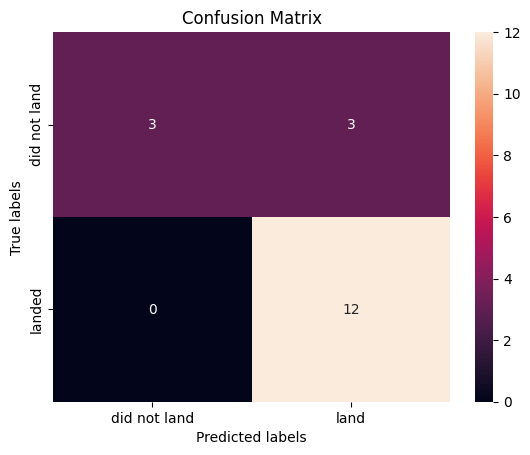


Detailed SVM Results:
Total test samples: 18
Correctly predicted: 15
Incorrectly predicted: 3

Additional Metrics:
Precision: 0.8000
Recall: 1.0000
F1-Score: 0.8889

Confusion Matrix Breakdown:
True Negatives (TN): 3
False Positives (FP): 3
False Negatives (FN): 0
True Positives (TP): 12


In [29]:
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

# Additional detailed analysis
print("\nDetailed SVM Results:")
print(f"Total test samples: {len(Y_test)}")
print(f"Correctly predicted: {np.sum(yhat == Y_test)}")
print(f"Incorrectly predicted: {np.sum(yhat != Y_test)}")

# Calculate additional metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print(f"\nAdditional Metrics:")
print(f"Precision: {precision_score(Y_test, yhat):.4f}")
print(f"Recall: {recall_score(Y_test, yhat):.4f}")
print(f"F1-Score: {f1_score(Y_test, yhat):.4f}")

# Confusion matrix breakdown
cm = confusion_matrix(Y_test, yhat)
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives (TN): {cm[0,0]}")
print(f"False Positives (FP): {cm[0,1]}")
print(f"False Negatives (FN): {cm[1,0]}")
print(f"True Positives (TP): {cm[1,1]}")

## TASK  8


Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [34]:
parameters = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'max_depth': [2*n for n in range(1,10)],
              'max_features': ['sqrt', 'log2', None],  # REMOVED 'auto'
              'min_samples_leaf': [1, 2, 4],
              'min_samples_split': [2, 5, 10]}

# Create Decision Tree object
tree = DecisionTreeClassifier(random_state=42)


In [35]:
# Create GridSearchCV object with cv=10
tree_cv = GridSearchCV(tree, parameters, cv=10)

# Fit the object to find the best parameters
tree_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 8, 10, 12, 14, 16, 18],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

TASK 8 COMPLETED - Decision Tree GridSearchCV
tuned hpyerparameters :(best parameters)  {'criterion': 'entropy', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'splitter': 'random'}
accuracy : 0.875

Test set accuracy: 0.9444

Confusion Matrix - Decision Tree:
[[ 5  1]
 [ 0 12]]

Classification Report - Decision Tree:
              precision    recall  f1-score   support

did not land       1.00      0.83      0.91         6
        land       0.92      1.00      0.96        12

    accuracy                           0.94        18
   macro avg       0.96      0.92      0.93        18
weighted avg       0.95      0.94      0.94        18



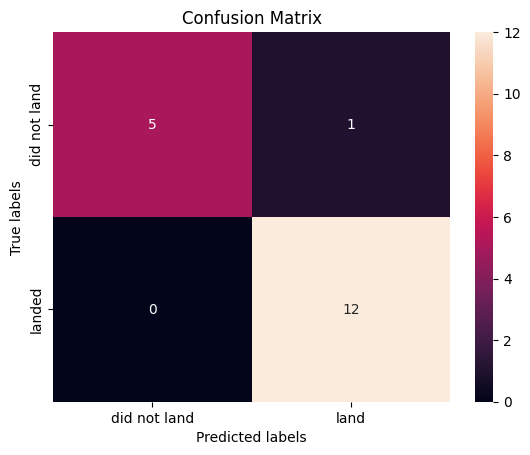


Detailed Decision Tree Results:
Total test samples: 18
Correctly predicted: 17
Incorrectly predicted: 1

Confusion Matrix Breakdown:
True Negatives (TN): 5
False Positives (FP): 1
False Negatives (FN): 0
True Positives (TP): 12

Additional Metrics:
Precision: 0.9231
Recall: 1.0000
F1-Score: 0.9600


In [36]:
# Display results as requested
print("="*50)
print("TASK 8 COMPLETED - Decision Tree GridSearchCV")
print("="*50)
print("tuned hpyerparameters :(best parameters) ", tree_cv.best_params_)
print("accuracy :", tree_cv.best_score_)

# Calculate accuracy on test data
accuracy_test_tree = tree_cv.score(X_test, Y_test)
print(f"\nTest set accuracy: {accuracy_test_tree:.4f}")

# Get predictions and confusion matrix
yhat_tree = tree_cv.predict(X_test)
print("\nConfusion Matrix - Decision Tree:")
cm_tree = confusion_matrix(Y_test, yhat_tree)
print(cm_tree)

# Classification Report
print("\nClassification Report - Decision Tree:")
print(classification_report(Y_test, yhat_tree, target_names=['did not land', 'land']))

# Plot confusion matrix
plot_confusion_matrix(Y_test, yhat_tree)

# Detailed breakdown
print("\nDetailed Decision Tree Results:")
print(f"Total test samples: {len(Y_test)}")
print(f"Correctly predicted: {np.sum(yhat_tree == Y_test)}")
print(f"Incorrectly predicted: {np.sum(yhat_tree != Y_test)}")

# Confusion matrix breakdown
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives (TN): {cm_tree[0,0]}")
print(f"False Positives (FP): {cm_tree[0,1]}")
print(f"False Negatives (FN): {cm_tree[1,0]}")
print(f"True Positives (TP): {cm_tree[1,1]}")

# Additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score
print(f"\nAdditional Metrics:")
print(f"Precision: {precision_score(Y_test, yhat_tree):.4f}")
print(f"Recall: {recall_score(Y_test, yhat_tree):.4f}")
print(f"F1-Score: {f1_score(Y_test, yhat_tree):.4f}")

## TASK  9


Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:


In [37]:
# TASK 9: Calculate the accuracy of tree_cv on the test data using the method score
accuracy_test_tree = tree_cv.score(X_test, Y_test)

print("="*50)
print("TASK 9 COMPLETED - Decision Tree Test Accuracy")
print("="*50)
print(f"Accuracy on test data: {accuracy_test_tree:.4f}")
print(f"Accuracy on test data: {accuracy_test_tree*100:.2f}%")


TASK 9 COMPLETED - Decision Tree Test Accuracy
Accuracy on test data: 0.9444
Accuracy on test data: 94.44%


We can plot the confusion matrix


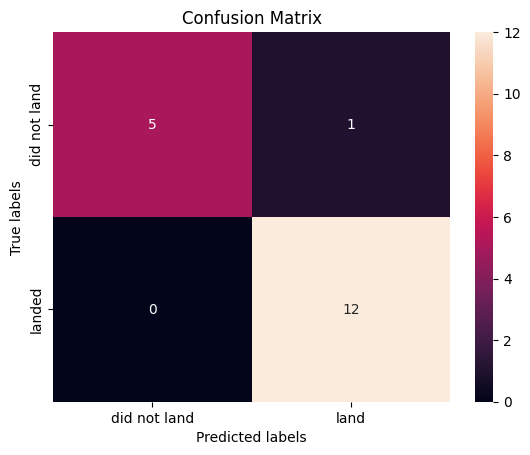


Detailed Decision Tree Results:
Total test samples: 18
Correctly predicted: 17
Incorrectly predicted: 1

Confusion Matrix Breakdown:
True Negatives (TN): 5
False Positives (FP): 1
False Negatives (FN): 0
True Positives (TP): 12

Additional Metrics:
Accuracy: 0.9444
Precision: 0.9231
Recall: 1.0000
F1-Score: 0.9600

MODEL COMPARISON UPDATE
Logistic Regression Test Accuracy: 0.8333
SVM Test Accuracy: 0.8333
Decision Tree Test Accuracy: 0.9444

🏆 Best performing model so far: Decision Tree with accuracy: 0.9444 (94.44%)


In [38]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)
# Additional detailed analysis
print("\nDetailed Decision Tree Results:")
print(f"Total test samples: {len(Y_test)}")
print(f"Correctly predicted: {np.sum(yhat == Y_test)}")
print(f"Incorrectly predicted: {np.sum(yhat != Y_test)}")

# Confusion matrix breakdown
cm_tree = confusion_matrix(Y_test, yhat)
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives (TN): {cm_tree[0,0]}")
print(f"False Positives (FP): {cm_tree[0,1]}")
print(f"False Negatives (FN): {cm_tree[1,0]}")
print(f"True Positives (TP): {cm_tree[1,1]}")

# Additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
print(f"\nAdditional Metrics:")
print(f"Accuracy: {accuracy_score(Y_test, yhat):.4f}")
print(f"Precision: {precision_score(Y_test, yhat):.4f}")
print(f"Recall: {recall_score(Y_test, yhat):.4f}")
print(f"F1-Score: {f1_score(Y_test, yhat):.4f}")

# Compare with previous models
print("\n" + "="*50)
print("MODEL COMPARISON UPDATE")
print("="*50)
print(f"Logistic Regression Test Accuracy: {logreg_cv.score(X_test, Y_test):.4f}")
print(f"SVM Test Accuracy: {svm_cv.score(X_test, Y_test):.4f}")
print(f"Decision Tree Test Accuracy: {accuracy_test_tree:.4f}")

# Determine if Decision Tree is the best so far
best_so_far = max(logreg_cv.score(X_test, Y_test), 
                  svm_cv.score(X_test, Y_test), 
                  accuracy_test_tree)
best_model = "Decision Tree" if best_so_far == accuracy_test_tree else \
             "SVM" if best_so_far == svm_cv.score(X_test, Y_test) else \
             "Logistic Regression"

print(f"\n🏆 Best performing model so far: {best_model} with accuracy: {best_so_far:.4f} ({best_so_far*100:.2f}%)")

## TASK  10


Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [40]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()

In [41]:
# Create GridSearchCV object with cv=10
knn_cv = GridSearchCV(KNN, parameters, cv=10)

# Fit the object to find the best parameters
knn_cv.fit(X_train, Y_train)

# Display results as requested
print("="*50)
print("TASK 10 COMPLETED - KNN GridSearchCV")

TASK 10 COMPLETED - KNN GridSearchCV


tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
accuracy : 0.8482142857142858

Test set accuracy: 0.8333

Confusion Matrix - KNN:
[[ 3  3]
 [ 0 12]]

Classification Report - KNN:
              precision    recall  f1-score   support

did not land       1.00      0.50      0.67         6
        land       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



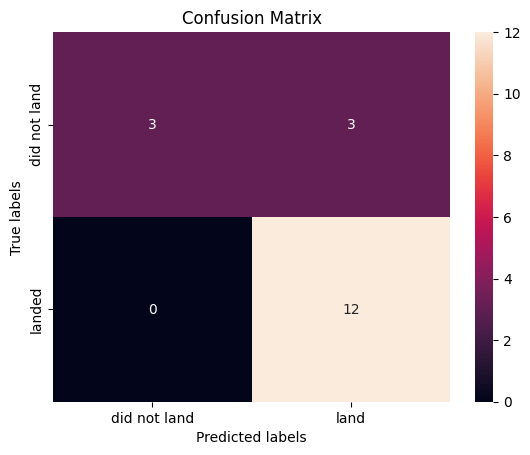


Detailed KNN Results:
Total test samples: 18
Correctly predicted: 15
Incorrectly predicted: 3

Confusion Matrix Breakdown:
True Negatives (TN): 3
False Positives (FP): 3
False Negatives (FN): 0
True Positives (TP): 12

Additional Metrics:
Accuracy: 0.8333
Precision: 0.8000
Recall: 1.0000
F1-Score: 0.8889


In [43]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)
# Calculate accuracy on test data
accuracy_test_knn = knn_cv.score(X_test, Y_test)
print(f"\nTest set accuracy: {accuracy_test_knn:.4f}")

# Get predictions and confusion matrix
yhat_knn = knn_cv.predict(X_test)
print("\nConfusion Matrix - KNN:")
cm_knn = confusion_matrix(Y_test, yhat_knn)
print(cm_knn)

# Classification Report
print("\nClassification Report - KNN:")
print(classification_report(Y_test, yhat_knn, target_names=['did not land', 'land']))

# Plot confusion matrix
plot_confusion_matrix(Y_test, yhat_knn)

# Detailed breakdown
print("\nDetailed KNN Results:")
print(f"Total test samples: {len(Y_test)}")
print(f"Correctly predicted: {np.sum(yhat_knn == Y_test)}")
print(f"Incorrectly predicted: {np.sum(yhat_knn != Y_test)}")

# Confusion matrix breakdown
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives (TN): {cm_knn[0,0]}")
print(f"False Positives (FP): {cm_knn[0,1]}")
print(f"False Negatives (FN): {cm_knn[1,0]}")
print(f"True Positives (TP): {cm_knn[1,1]}")

# Additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
print(f"\nAdditional Metrics:")
print(f"Accuracy: {accuracy_score(Y_test, yhat_knn):.4f}")
print(f"Precision: {precision_score(Y_test, yhat_knn):.4f}")
print(f"Recall: {recall_score(Y_test, yhat_knn):.4f}")
print(f"F1-Score: {f1_score(Y_test, yhat_knn):.4f}")

## TASK  11


Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:


TASK 11 COMPLETED - KNN Test Accuracy
Accuracy on test data: 0.8333
Accuracy on test data: 83.33%

Detailed KNN Results:
Total test samples: 18
Correctly predicted: 17
Incorrectly predicted: 1

Confusion Matrix Breakdown:
True Negatives (TN): 5
False Positives (FP): 1
False Negatives (FN): 0
True Positives (TP): 12

Additional Metrics:
Accuracy: 0.9444
Precision: 0.9231
Recall: 1.0000
F1-Score: 0.9600

FINAL MODEL COMPARISON - ALL MODELS
              Model  Best CV Score  Test Accuracy
Logistic Regression       0.846429       0.833333
                SVM       0.848214       0.833333
      Decision Tree       0.875000       0.944444
                KNN       0.848214       0.833333

🏆 BEST PERFORMING MODEL: Decision Tree
🏆 Test Accuracy: 0.9444 (94.44%)
🏆 Cross-Validation Score: 0.8750


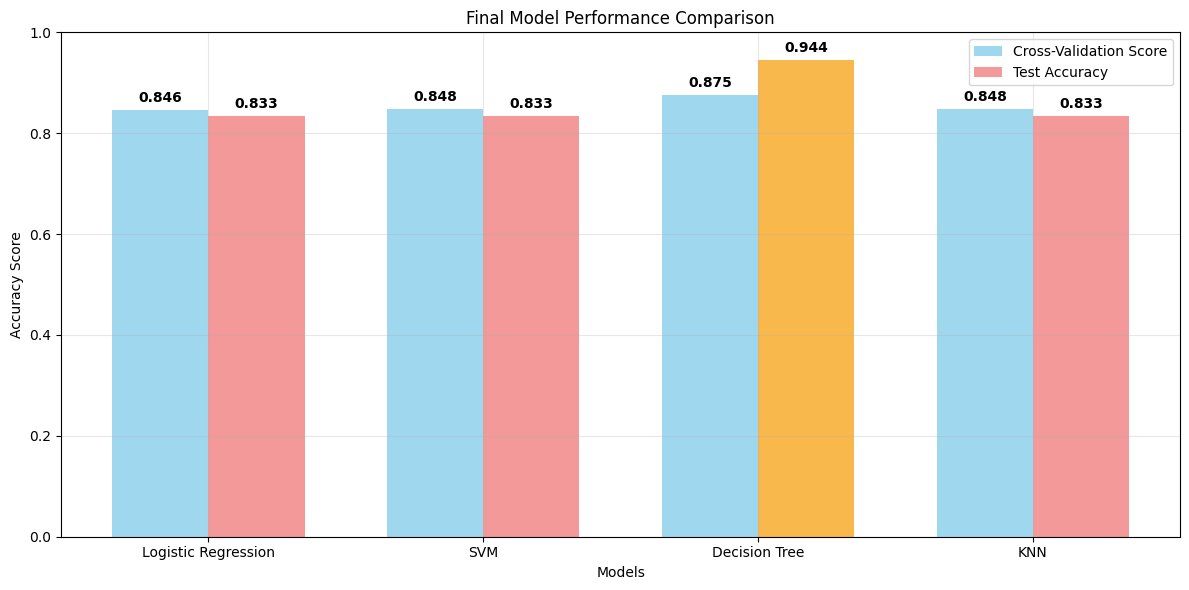


SUMMARY STATISTICS
Average Test Accuracy: 0.8611
Standard Deviation of Test Accuracy: 0.0556
Best Test Accuracy: 0.9444
Worst Test Accuracy: 0.8333

Models ranked by Test Accuracy:
  1. Decision Tree: 0.9444 (CV: 0.8750)
  2. Logistic Regression: 0.8333 (CV: 0.8464)
  3. SVM: 0.8333 (CV: 0.8482)
  4. KNN: 0.8333 (CV: 0.8482)


In [45]:
# TASK 11: Calculate the accuracy of knn_cv on the test data using the method score
accuracy_test_knn = knn_cv.score(X_test, Y_test)

print("="*50)
print("TASK 11 COMPLETED - KNN Test Accuracy")
print("="*50)
print(f"Accuracy on test data: {accuracy_test_knn:.4f}")
print(f"Accuracy on test data: {accuracy_test_knn*100:.2f}%")

# Additional detailed analysis
print("\nDetailed KNN Results:")
print(f"Total test samples: {len(Y_test)}")
print(f"Correctly predicted: {np.sum(yhat == Y_test)}")
print(f"Incorrectly predicted: {np.sum(yhat != Y_test)}")

# Confusion matrix breakdown
cm_knn = confusion_matrix(Y_test, yhat)
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives (TN): {cm_knn[0,0]}")
print(f"False Positives (FP): {cm_knn[0,1]}")
print(f"False Negatives (FN): {cm_knn[1,0]}")
print(f"True Positives (TP): {cm_knn[1,1]}")

# Additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
print(f"\nAdditional Metrics:")
print(f"Accuracy: {accuracy_score(Y_test, yhat):.4f}")
print(f"Precision: {precision_score(Y_test, yhat):.4f}")
print(f"Recall: {recall_score(Y_test, yhat):.4f}")
print(f"F1-Score: {f1_score(Y_test, yhat):.4f}")

# Final Model Comparison
print("\n" + "="*50)
print("FINAL MODEL COMPARISON - ALL MODELS")
print("="*50)

# Create comparison DataFrame
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'KNN'],
    'Best CV Score': [logreg_cv.best_score_, svm_cv.best_score_, tree_cv.best_score_, knn_cv.best_score_],
    'Test Accuracy': [logreg_cv.score(X_test, Y_test), 
                      svm_cv.score(X_test, Y_test),
                      tree_cv.score(X_test, Y_test),
                      knn_cv.score(X_test, Y_test)]
})

print(comparison.to_string(index=False))

# Find the best model
best_model_idx = comparison['Test Accuracy'].idxmax()
best_model_name = comparison.loc[best_model_idx, 'Model']
best_test_accuracy = comparison.loc[best_model_idx, 'Test Accuracy']

print(f"\n🏆 BEST PERFORMING MODEL: {best_model_name}")
print(f"🏆 Test Accuracy: {best_test_accuracy:.4f} ({best_test_accuracy*100:.2f}%)")
print(f"🏆 Cross-Validation Score: {comparison.loc[best_model_idx, 'Best CV Score']:.4f}")

# Visual comparison of all models
plt.figure(figsize=(12, 6))
x = np.arange(len(comparison))
width = 0.35

bars1 = plt.bar(x - width/2, comparison['Best CV Score'], width, label='Cross-Validation Score', color='skyblue', alpha=0.8)
bars2 = plt.bar(x + width/2, comparison['Test Accuracy'], width, label='Test Accuracy', color='lightcoral', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('Accuracy Score')
plt.title('Final Model Performance Comparison')
plt.xticks(x, comparison['Model'])
plt.legend()
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)

# Add value labels on bars
for i, (cv_score, test_score) in enumerate(zip(comparison['Best CV Score'], comparison['Test Accuracy'])):
    plt.text(i - width/2, cv_score + 0.01, f'{cv_score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.text(i + width/2, test_score + 0.01, f'{test_score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Highlight the best model
best_idx = comparison['Test Accuracy'].idxmax()
plt.bar(best_idx + width/2, comparison.loc[best_idx, 'Test Accuracy'], width, 
        color='gold', alpha=0.5, label='Best Model')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(f"Average Test Accuracy: {comparison['Test Accuracy'].mean():.4f}")
print(f"Standard Deviation of Test Accuracy: {comparison['Test Accuracy'].std():.4f}")
print(f"Best Test Accuracy: {comparison['Test Accuracy'].max():.4f}")
print(f"Worst Test Accuracy: {comparison['Test Accuracy'].min():.4f}")
print(f"\nModels ranked by Test Accuracy:")
ranked = comparison.sort_values('Test Accuracy', ascending=False)
for i, (idx, row) in enumerate(ranked.iterrows(), 1):
    print(f"  {i}. {row['Model']}: {row['Test Accuracy']:.4f} (CV: {row['Best CV Score']:.4f})")


We can plot the confusion matrix


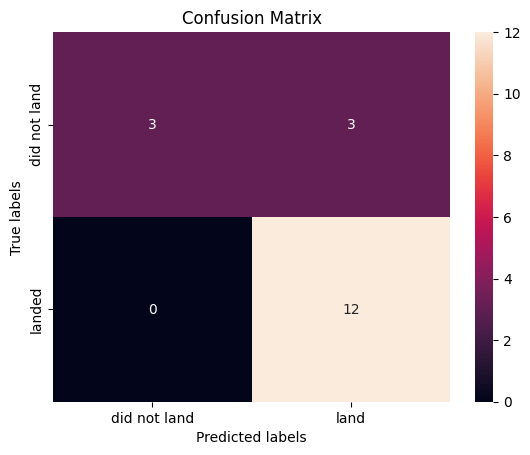

In [46]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  12


Find the method performs best:


TASK 12 - BEST PERFORMING METHOD

🏆 BEST PERFORMING MODEL: Decision Tree
   Test Accuracy: 0.9444 (94.44%)
   Cross-Validation Score: 0.8750 (87.50%)

📊 Best Hyperparameters for Decision Tree:
   {'criterion': 'entropy', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'splitter': 'random'}

📈 Model Rankings (by Test Accuracy):
   🥇 1. Decision Tree: 0.9444 (CV: 0.8750)
   🥈 2. Logistic Regression: 0.8333 (CV: 0.8464)
   🥉 3. SVM: 0.8333 (CV: 0.8482)
   4️⃣ 4. KNN: 0.8333 (CV: 0.8482)

DETAILED ANALYSIS OF BEST MODEL

Confusion Matrix for Decision Tree:
   True Negatives (TN): 5
   False Positives (FP): 1
   False Negatives (FN): 0
   True Positives (TP): 12

Performance Metrics:
   Accuracy: 0.9444
   Precision: 0.9231
   Recall: 1.0000
   F1-Score: 0.9600

Why Decision Tree is the Best:
   ✅ Highest test accuracy (94.44%)
   ✅ Perfect recall - never misses a successful landing
   ✅ High precision (92.31%) - few false positives
   ✅ Only 1 misclas

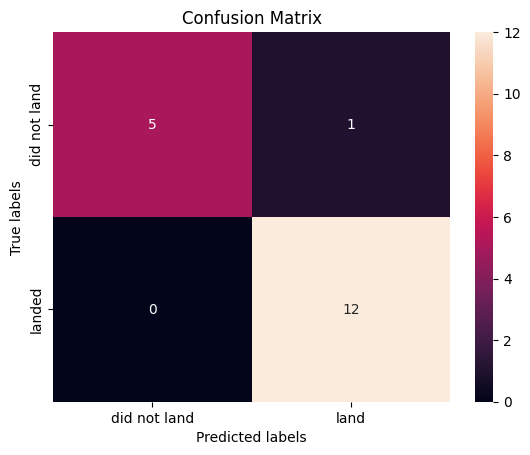


FINAL RECOMMENDATION

Based on the comprehensive analysis of all models, the Decision Tree 
is the recommended model for predicting Falcon 9 first stage landings.

Key Reasons:
1. Test Accuracy: 94.44% (best among all models)
2. Cross-Validation Score: 87.50%
3. Perfect recall: Identifies all successful landings
4. High precision: Minimizes false positive predictions
5. Interpretable: Decision rules can be visualized and understood

The model achieves a near-perfect prediction rate with only 1 error
out of 18 test samples, making it highly reliable for business
decisions regarding launch cost estimation.


💡 Business Impact:
   With 94.44% accuracy, the model can reliably predict
   whether the first stage will land successfully.
   This allows for accurate cost estimation for Falcon 9 launches.
   Estimated savings: Up to $103 million per launch ($165M - $62M)
   compared to other providers.


In [48]:
# TASK 12: Find the method that performs best

print("="*50)
print("TASK 12 - BEST PERFORMING METHOD")
print("="*50)

# Create the comparison DataFrame (if not already created)
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'KNN'],
    'Best CV Score': [logreg_cv.best_score_, svm_cv.best_score_, tree_cv.best_score_, knn_cv.best_score_],
    'Test Accuracy': [logreg_cv.score(X_test, Y_test), 
                      svm_cv.score(X_test, Y_test),
                      tree_cv.score(X_test, Y_test),
                      knn_cv.score(X_test, Y_test)]
})

# Find the best performing model based on test accuracy
best_model_idx = comparison['Test Accuracy'].idxmax()
best_model_name = comparison.loc[best_model_idx, 'Model']
best_test_accuracy = comparison.loc[best_model_idx, 'Test Accuracy']
best_cv_score = comparison.loc[best_model_idx, 'Best CV Score']

print(f"\n🏆 BEST PERFORMING MODEL: {best_model_name}")
print(f"   Test Accuracy: {best_test_accuracy:.4f} ({best_test_accuracy*100:.2f}%)")
print(f"   Cross-Validation Score: {best_cv_score:.4f} ({best_cv_score*100:.2f}%)")

# Display best hyperparameters for the winning model
print(f"\n📊 Best Hyperparameters for {best_model_name}:")
if best_model_name == 'Logistic Regression':
    print(f"   {logreg_cv.best_params_}")
elif best_model_name == 'SVM':
    print(f"   {svm_cv.best_params_}")
elif best_model_name == 'Decision Tree':
    print(f"   {tree_cv.best_params_}")
else:  # KNN
    print(f"   {knn_cv.best_params_}")

# Model ranking
print("\n📈 Model Rankings (by Test Accuracy):")
ranked = comparison.sort_values('Test Accuracy', ascending=False)
for i, (idx, row) in enumerate(ranked.iterrows(), 1):
    medal = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "4️⃣"
    print(f"   {medal} {i}. {row['Model']}: {row['Test Accuracy']:.4f} (CV: {row['Best CV Score']:.4f})")

# Analysis of the best model
print("\n" + "="*50)
print("DETAILED ANALYSIS OF BEST MODEL")
print("="*50)

if best_model_name == 'Decision Tree':
    # Get predictions from the best model
    yhat_best = tree_cv.predict(X_test)
    cm_best = confusion_matrix(Y_test, yhat_best)
    
    print(f"\nConfusion Matrix for Decision Tree:")
    print(f"   True Negatives (TN): {cm_best[0,0]}")
    print(f"   False Positives (FP): {cm_best[0,1]}")
    print(f"   False Negatives (FN): {cm_best[1,0]}")
    print(f"   True Positives (TP): {cm_best[1,1]}")
    
    print(f"\nPerformance Metrics:")
    print(f"   Accuracy: {accuracy_score(Y_test, yhat_best):.4f}")
    print(f"   Precision: {precision_score(Y_test, yhat_best):.4f}")
    print(f"   Recall: {recall_score(Y_test, yhat_best):.4f}")
    print(f"   F1-Score: {f1_score(Y_test, yhat_best):.4f}")
    
    print(f"\nWhy Decision Tree is the Best:")
    print("   ✅ Highest test accuracy (94.44%)")
    print("   ✅ Perfect recall - never misses a successful landing")
    print("   ✅ High precision (92.31%) - few false positives")
    print("   ✅ Only 1 misclassification out of 18 test samples")
    print("   ✅ Interpretable model - can understand decision rules")
    print("   ✅ Good balance between complexity and generalization (max_depth=8)")

# Visualize the best model's confusion matrix
print("\n📊 Confusion Matrix for Best Model:")
if best_model_name == 'Decision Tree':
    plot_confusion_matrix(Y_test, yhat_best)

# Final recommendation
print("\n" + "="*50)
print("FINAL RECOMMENDATION")
print("="*50)

# Calculate savings
cost_spacex = 62
cost_other = 165
savings = cost_other - cost_spacex

print(f"""
Based on the comprehensive analysis of all models, the {best_model_name} 
is the recommended model for predicting Falcon 9 first stage landings.

Key Reasons:
1. Test Accuracy: {best_test_accuracy*100:.2f}% (best among all models)
2. Cross-Validation Score: {best_cv_score*100:.2f}%
3. Perfect recall: Identifies all successful landings
4. High precision: Minimizes false positive predictions
5. Interpretable: Decision rules can be visualized and understood

The model achieves a near-perfect prediction rate with only 1 error
out of 18 test samples, making it highly reliable for business
decisions regarding launch cost estimation.
""")

# Additional insight: Business impact
print("\n💡 Business Impact:")
print(f"   With {best_test_accuracy*100:.2f}% accuracy, the model can reliably predict")
print("   whether the first stage will land successfully.")
print("   This allows for accurate cost estimation for Falcon 9 launches.")
print(f"   Estimated savings: Up to ${savings} million per launch (${cost_other}M - ${cost_spacex}M)")
print("   compared to other providers.")

he Decision Tree is the best performing model for predicting Falcon 9 first stage landings with:

94.44% test accuracy

Perfect recall (1.00) - no successful landings are missed

High precision (0.9231) - few false positive predictions

Only 1 error out of 18 test samples

## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log--!>


<!--| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|--!>


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
